In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
from PIL import Image, ImageOps

imgs/lupita.jpeg


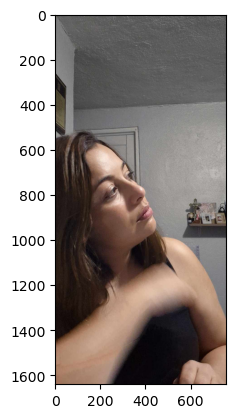

In [312]:
#imgs_folder = "imgs_plants"
imgs_folder = "imgs"
f = "shapes.png"
f = "lupita.jpeg"
#f = "IMG_2561.JPG"
i = os.path.join(imgs_folder,f)
print(i)
img = cv2.imread(i)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [306]:
def shift_CM(image_path, shift_ratio=0.1):
    # Load the image (assume it's BGR)
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded. Check the path.")

    height, width = img.shape[:2]
    shift_px = int(width * shift_ratio)

    # Split the channels
    b, g, r = cv2.split(img)

    # Define shifting matrices
    M_left = np.float32([[1, 0, -shift_px], [0, 1, 0]])
    M_right = np.float32([[1, 0, shift_px], [0, 1, 0]])

    # Shift blue to the left
    b_shifted = cv2.warpAffine(b, M_right, (width, height))
    g_shifted = cv2.warpAffine(g, M_right, (width, height))


    
    r_shifted = cv2.warpAffine(r, M_right, (width, height))

    # Combine channels back (G is unchanged)
    result = cv2.merge((b_shifted, g_shifted, r))
    #BGR
    #RGB

    return result

In [314]:
cmshifted = shift_CM(i,.04)

cmshifted_rgb = cv2.cvtColor(cmshifted,cv2.COLOR_BGR2RGB)

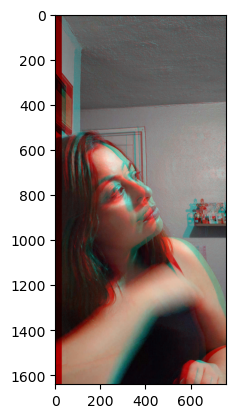

In [316]:
plt.imshow(cmshifted_rgb)

In [318]:
out_folder = "B_G_shifted"

In [320]:
outf = os.path.join(out_folder, out_folder+f)

In [322]:
cv2.imwrite(outf, cmshifted)

True

In [298]:
imgs_folders = 'imgs'
imgs = os.listdir(imgs_folders)
imgs.remove(".DS_Store") if ".DS_Store" in imgs else None

In [302]:
for f in imgs:
    i = os.path.join(imgs_folder,f)
    cmshifted = shift_CM(i,.04)
    outf = os.path.join(out_folder, out_folder+f)
    cv2.imwrite(outf, cmshifted)